# 02 — Time Series Analysis
Vaccination trends for top countries over time.

In [1]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
with open(os.path.join("..", "data", "processed.pkl"), "rb") as f:
    df = pickle.load(f)

df["date"] = pd.to_datetime(df["date"])
print(f"Shape: {df.shape}")

Shape: (62980, 21)


In [3]:
# figure out the top 8 countries by peak total_vaccinations
peak = df.groupby("location")["total_vaccinations"].max().nlargest(8)
top8 = peak.index.tolist()
print("Top 8:", top8)

sub = df[df["location"].isin(top8)].copy()

Top 8: ['China', 'India', 'United States', 'Brazil', 'Indonesia', 'Japan', 'Bangladesh', 'Pakistan']


## 1. Total vaccinations over time

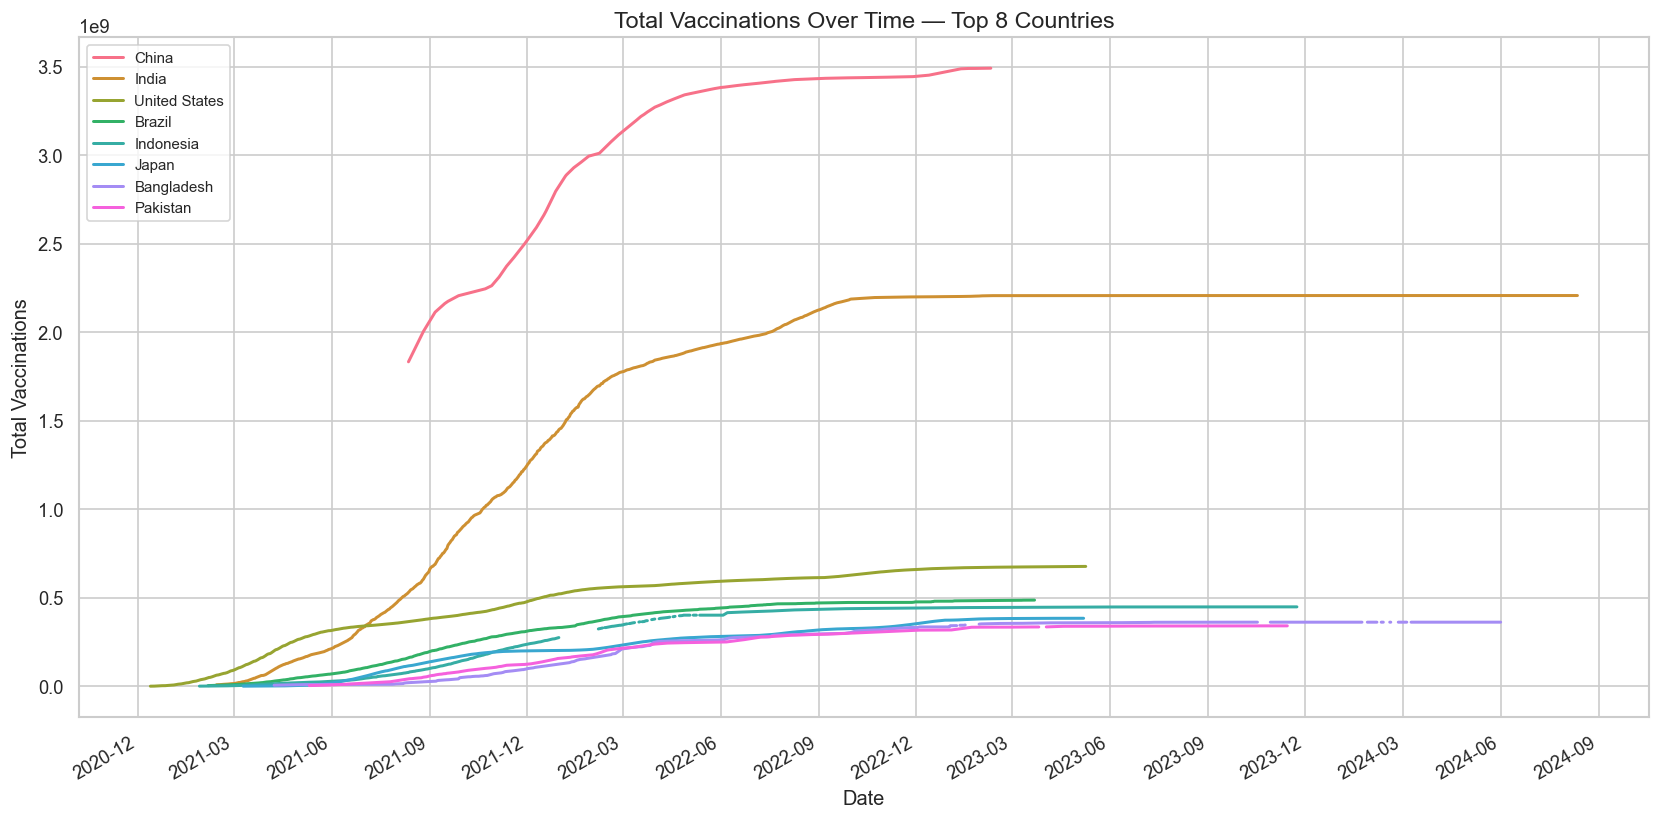

In [4]:
palette = sns.color_palette("husl", 8)

fig, ax = plt.subplots(figsize=(14, 7))
for i, country in enumerate(top8):
    chunk = sub[sub["location"] == country].sort_values("date")
    ax.plot(chunk["date"], chunk["total_vaccinations"], label=country,
            color=palette[i], linewidth=1.8)

ax.set_title("Total Vaccinations Over Time — Top 8 Countries", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Vaccinations")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "total_vaccinations_top8.png"))
plt.show()

## 2. Fully vaccinated % with rolling average + annotated periods

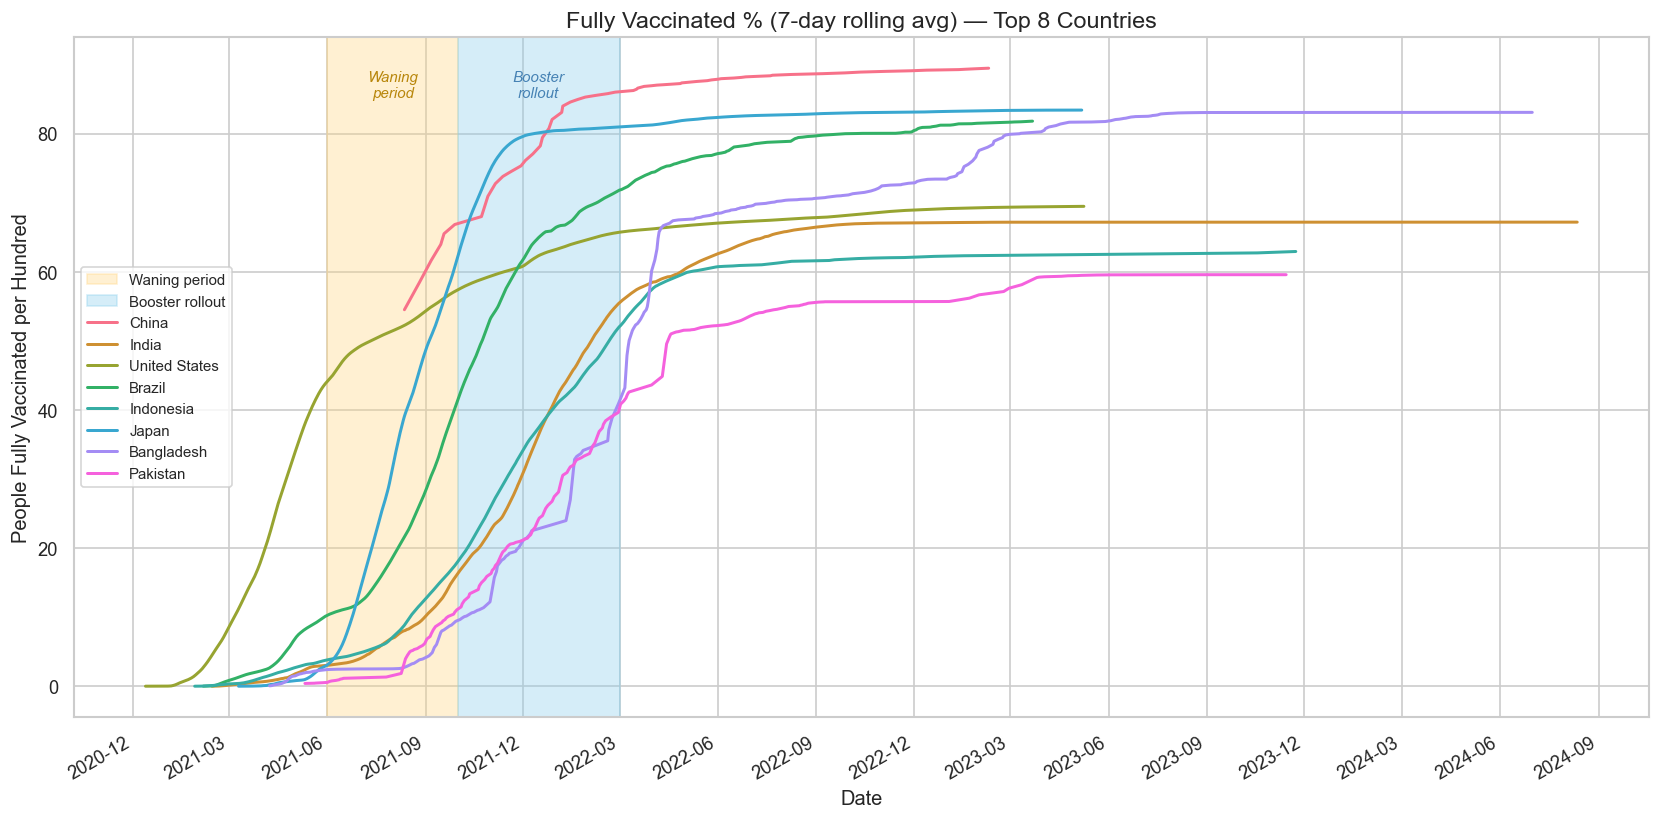

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

# shade waning period first (behind the lines)
ax.axvspan(pd.Timestamp("2021-06-01"), pd.Timestamp("2021-10-01"),
           color="#FFD580", alpha=0.35, label="Waning period")

# shade booster rollout
ax.axvspan(pd.Timestamp("2021-10-01"), pd.Timestamp("2022-03-01"),
           color="#87CEEB", alpha=0.35, label="Booster rollout")

for i, country in enumerate(top8):
    chunk = sub[sub["location"] == country].sort_values("date").copy()
    chunk["smooth"] = chunk["people_fully_vaccinated_per_hundred"].rolling(7, min_periods=1).mean()
    ax.plot(chunk["date"], chunk["smooth"], label=country,
            color=palette[i], linewidth=1.8)

# add text labels for the shaded regions
ax.text(pd.Timestamp("2021-08-01"), ax.get_ylim()[1] * 0.95,
        "Waning\nperiod", ha="center", va="top", fontsize=9,
        fontstyle="italic", color="#B8860B")
ax.text(pd.Timestamp("2021-12-15"), ax.get_ylim()[1] * 0.95,
        "Booster\nrollout", ha="center", va="top", fontsize=9,
        fontstyle="italic", color="#4682B4")

ax.set_title("Fully Vaccinated % (7-day rolling avg) — Top 8 Countries", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("People Fully Vaccinated per Hundred")
ax.legend(loc="center left", fontsize=9, ncol=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "fully_vaccinated_pct_top8.png"))
plt.show()